# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [1]:
# Importing necessary libraries

import numpy as np; import pandas as pd; from matplotlib import pyplot as plt; import seaborn as sns # Data processing and visualisation
from sklearn.model_selection import train_test_split  # Train-test split
from sklearn.linear_model import LinearRegression # Linear Regression Model
from sklearn.model_selection import GridSearchCV  # Cross-validation
from sklearn.linear_model import LinearRegression, Lasso, Ridge  # Linear regression model + lasso and ridge regularisation models
from sklearn.preprocessing import MinMaxScaler  # Scaling
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, accuracy_score, mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error  # Error metrics
import warnings; warnings.filterwarnings('ignore') 

#### **1.1.1**
Load the dataset

In [2]:
# Load the data
df = pd.read_csv('Car_Price_data.csv'); df.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

In [4]:
# Find the proportion of missing values in each column and handle if found

*Answer:*
**No missing values**

**Observation:**  
The dataset contains a mix of numerical and categorical variables, with several categorical features showing strong class imbalance.  
Some features also contain high-cardinality or text-based values, indicating the need for consolidation or feature engineering before modeling.

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

In [5]:
df.columns

Index(['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel',
       'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras',
       'Safety_Security', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new',
       'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc',
       'Weight_kg', 'Drive_chain', 'cons_comb'],
      dtype='object')

In [6]:
# Identify numerical features and plot histograms
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns

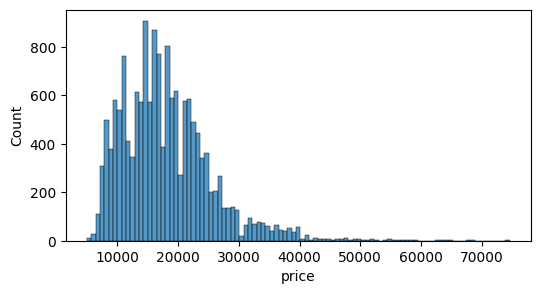

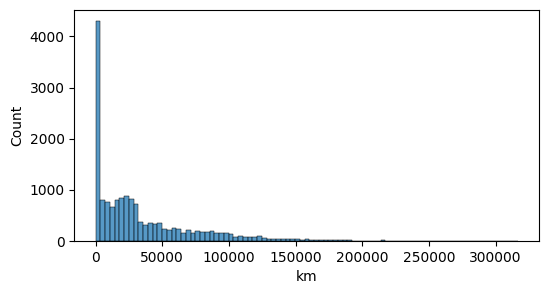

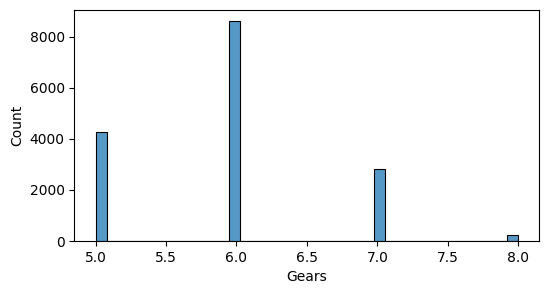

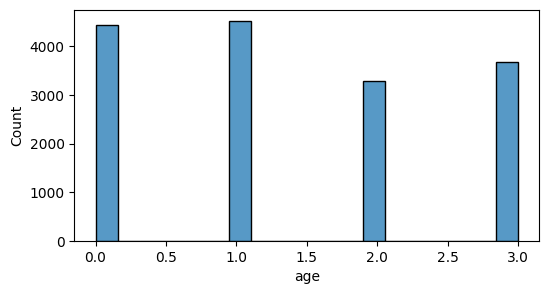

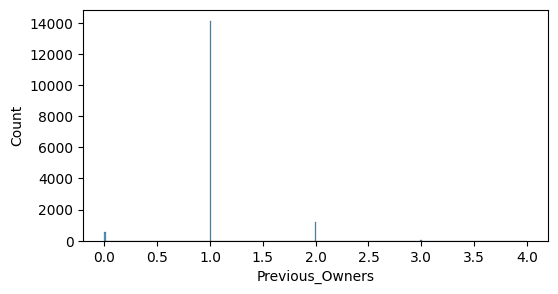

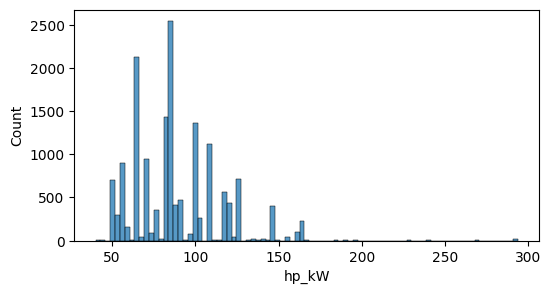

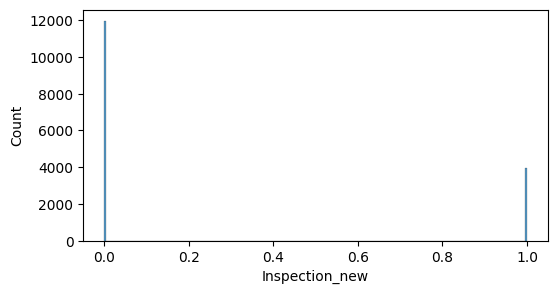

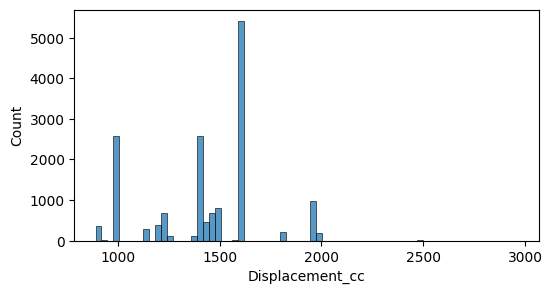

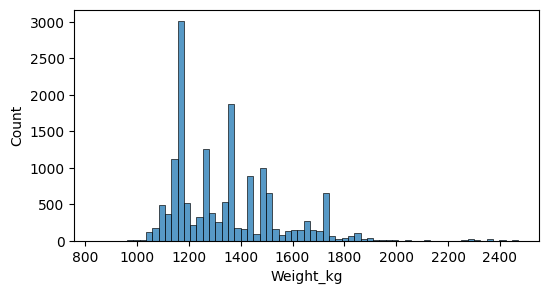

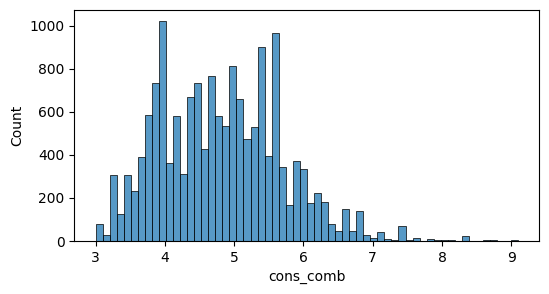

In [7]:
for col in num_cols: 
    plt.figure(figsize=(6,3))
    sns.histplot(data=df, x=col)
    plt.show()

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

In [8]:
category_cols = df.select_dtypes(include = 'object').columns

In [9]:
# Identify categorical columns and check their frequency distributions
df_category = df.drop(num_cols, axis=1)

In [10]:
df_category.columns

Index(['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience',
       'Entertainment_Media', 'Extras', 'Safety_Security', 'Paint_Type',
       'Upholstery_type', 'Gearing_Type', 'Drive_chain'],
      dtype='object')

In [11]:
for col in df_category.columns:
    df_uni = df_category[col].nunique()
    print(F'{col}:{df_uni}')

make_model:9
body_type:8
vat:2
Type:5
Fuel:4
Comfort_Convenience:6196
Entertainment_Media:346
Extras:659
Safety_Security:4442
Paint_Type:3
Upholstery_type:2
Gearing_Type:3
Drive_chain:3


In [12]:
df_temp = df[["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]]

In [13]:
df_temp.values

array([['Air conditioning,Armrest,Automatic climate control,Cruise control,Electrical side mirrors,Hill Holder,Leather steering wheel,Light sensor,Multi-function steering wheel,Navigation system,Park Distance Control,Parking assist system sensors rear,Power windows,Rain sensor,Seat heating,Start-stop system',
        'Bluetooth,Hands-free equipment,On-board computer,Radio',
        'Alloy wheels,Catalytic Converter,Voice Control',
        'ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control,Xenon headlights'],
       ['Air conditioning,Automatic climate control,Hill Holder,Leather steering wheel,Lumbar support,Parking assist system sensors rear,Power windows,Start-stop system,Tinted windows',
        'Bluetooth,Hands-free equipment,On-board computer,Radio,Sound system',
        'Alloy wheels,Sport seats,Sport suspension

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [14]:
# Fix columns as needed

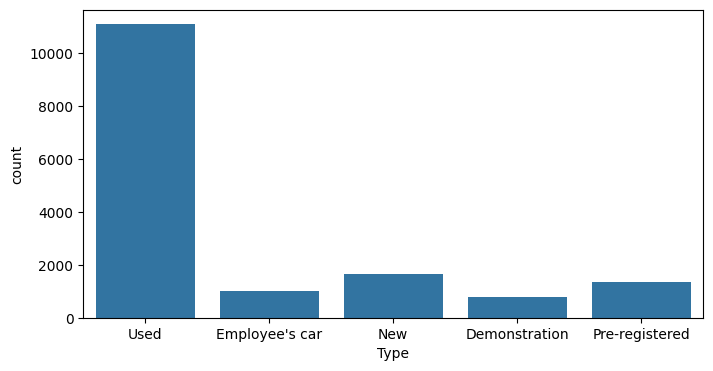

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x=df['Type'])
plt.show()

In [16]:
df.groupby('Type')['Type'].value_counts()

Type
Demonstration       796
Employee's car     1011
New                1649
Pre-registered     1364
Used              11095
Name: count, dtype: int64

In [17]:
df['Type'] = df['Type'].replace({
    'Pre-registered': 'New-like',
    'New': 'New-like',
    'Demonstration': 'Used-lightly',
    "Employee's car": 'Used-lightly'
}); df.groupby('Type')['Type'].value_counts()


Type
New-like         3013
Used            11095
Used-lightly     1807
Name: count, dtype: int64

In [83]:
df_cat_1 = df_category.drop(["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"], axis=1)

In [84]:
for col in df_cat_1.columns:
    count = df_cat_1.groupby(col)[col].value_counts()
    print(count)

make_model
Audi A1           2614
Audi A2              1
Audi A3           3097
Opel Astra        2525
Opel Corsa        2216
Opel Insignia     2598
Renault Clio      1839
Renault Duster      34
Renault Espace     991
Name: count, dtype: int64
body_type
Compact          3240
Convertible         8
Coupe              25
Off-Road           56
Sedans           8004
Station wagon    3677
Transporter        88
Van               817
Name: count, dtype: int64
vat
Price negotiable      871
VAT deductible      15044
Name: count, dtype: int64
Type
Demonstration       796
Employee's car     1011
New                1649
Pre-registered     1364
Used              11095
Name: count, dtype: int64
Fuel
Benzine     8548
Diesel      7298
Electric       5
LPG/CNG       64
Name: count, dtype: int64
Paint_Type
Metallic       15246
Perl effect       32
Uni/basic        637
Name: count, dtype: int64
Upholstery_type
Cloth                12234
Part/Full Leather     3681
Name: count, dtype: int64
Gearing_Type
Aut

In [19]:
# Converting make_model column to brand column
df['brand'] = df['make_model'].str.split().str[0]
df.drop(columns='make_model', inplace=True)

In [20]:
# Converting values with very less count in body_type to Others
df['body_type'] = df['body_type'].replace(
    ['Convertible', 'Coupe', 'Off-Road', 'Transporter'],
    'Other'
)

In [21]:
# Converting values with very less count in Fuel to Others
df['Fuel'] = df['Fuel'].replace(
    ['Electric', 'LPG/CNG'],
    'Other'
)

In [22]:
# Converting values with very less count in Paint_Type to Others
df['Paint_Type'] = df['Paint_Type'].replace(
    ['Perl effect'],
    'Other'
)

In [23]:
# Converting values with very less count in Drive_chain to Others
df['Drive_chain'] = df['Drive_chain'].replace(
    ['rear', '4WD'],
    'Other'
)

*Low-frequency categories were identified using value counts.*
*The make_model feature was decomposed into a brand variable to avoid sparse categories caused by rare models.*
*For body_type, rare categories such as Convertible, Coupe, Off-Road, and Transporter were grouped into an “Other” class.*
*Fuel types with very low representation (Electric, LPG/CNG) and paint types with minimal frequency were similarly consolidated.*
*Binary and well-balanced features such as VAT, upholstery type, and gearing type were retained without modification.*
*This strategy reduces sparsity while preserving meaningful information for modeling.*

#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

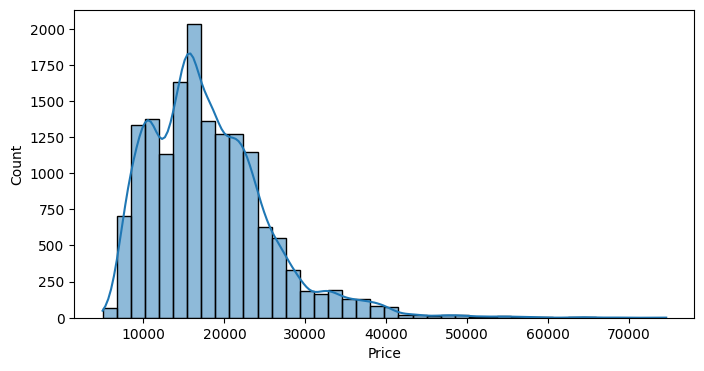

In [24]:
# Plot histograms for target feature
plt.figure(figsize=(8,4))
sns.histplot(data=df, x=df['price'], bins=40, kde=True)
plt.xlabel('Price')
plt.show()


**The target variable seems to be skewed. Perform suitable transformation on the target.**

**Interpretation:**  
The price distribution is heavily right-skewed with a long tail, indicating the presence of extreme values.  
To stabilize variance and reduce the influence of outliers, a logarithmic transformation of the target variable is applied.

In [25]:
# Transform the target feature
df['price'].describe()

count    15915.000000
mean     18024.380584
std       7381.679318
min       4950.000000
25%      12850.000000
50%      16900.000000
75%      21900.000000
max      74600.000000
Name: price, dtype: float64

In [26]:
df['log_price'] = np.log(df['price'])

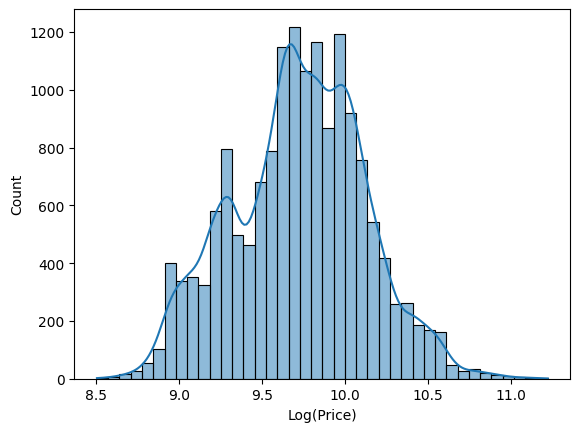

In [27]:
sns.histplot(df['log_price'], bins=40, kde=True)
plt.xlabel('Log(Price)')
plt.show()

**Interpretation:**  
After log transformation, the target variable becomes more symmetric and closer to a normal distribution.  
This improves the suitability of linear regression models and reduces heteroscedasticity in residuals.

### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

In [28]:
df_category.columns

Index(['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience',
       'Entertainment_Media', 'Extras', 'Safety_Security', 'Paint_Type',
       'Upholstery_type', 'Gearing_Type', 'Drive_chain'],
      dtype='object')

In [29]:
df_num = df.drop(['brand', 'body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience',
       'Entertainment_Media', 'Extras', 'Safety_Security', 'Paint_Type',
       'Upholstery_type', 'Gearing_Type', 'Drive_chain'], axis=1)

In [30]:
# Visualise correlation
corr_matrix = df_num.corr(method='pearson')

<Axes: >

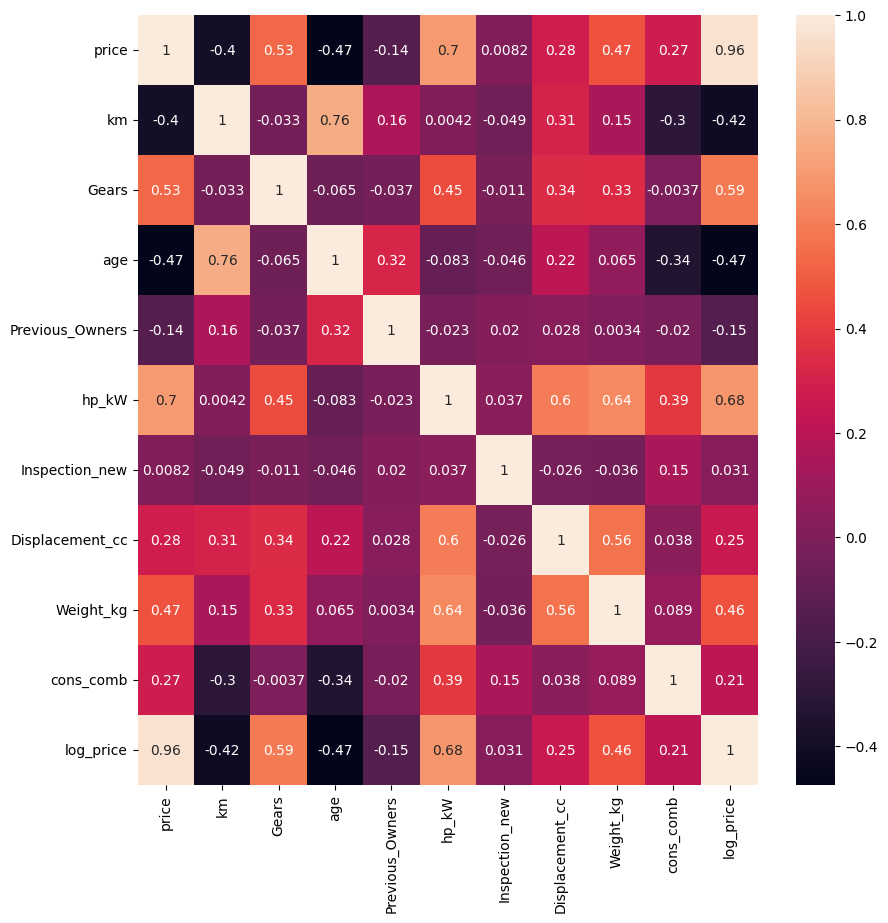

In [31]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True)

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

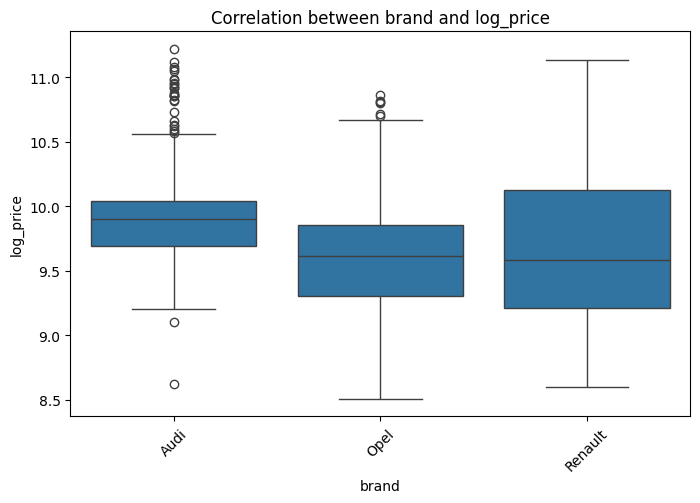

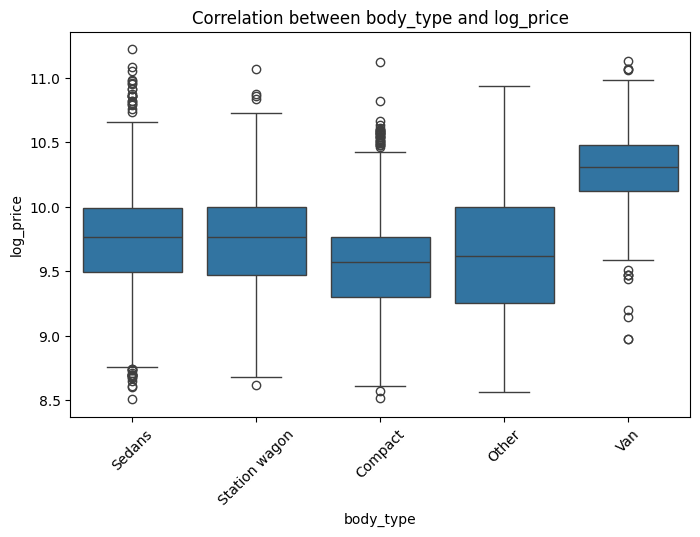

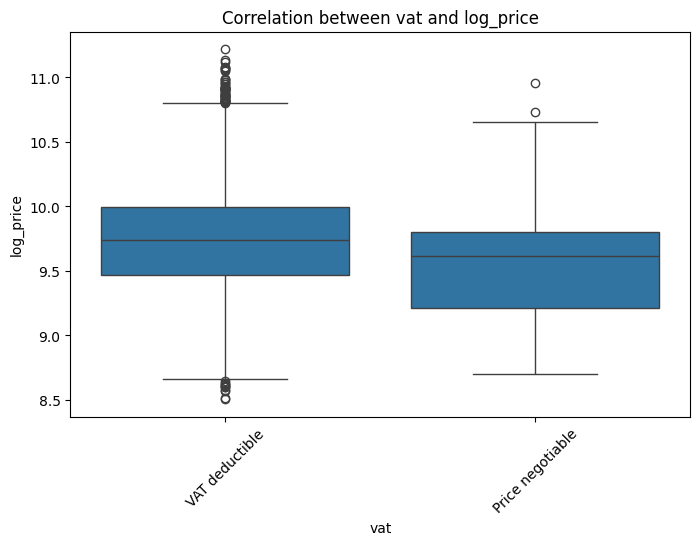

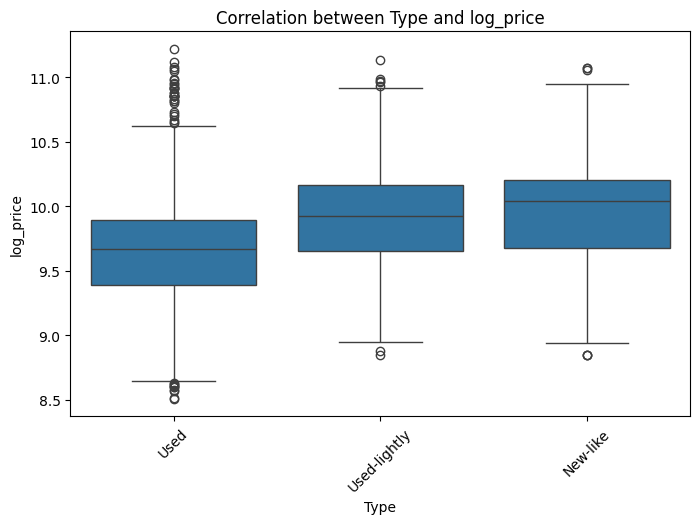

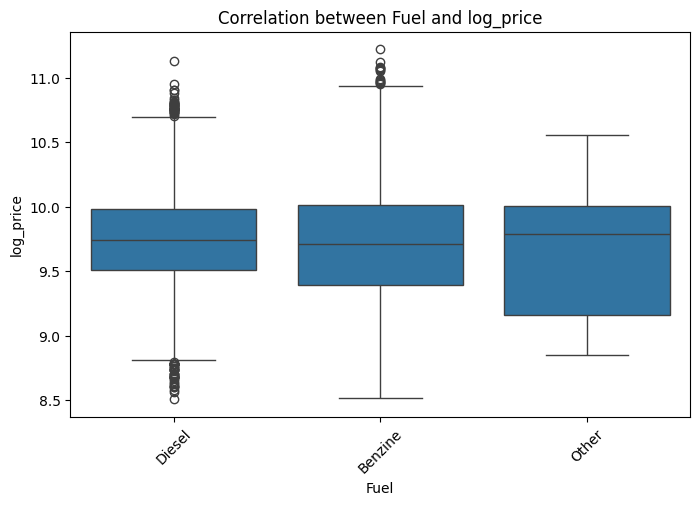

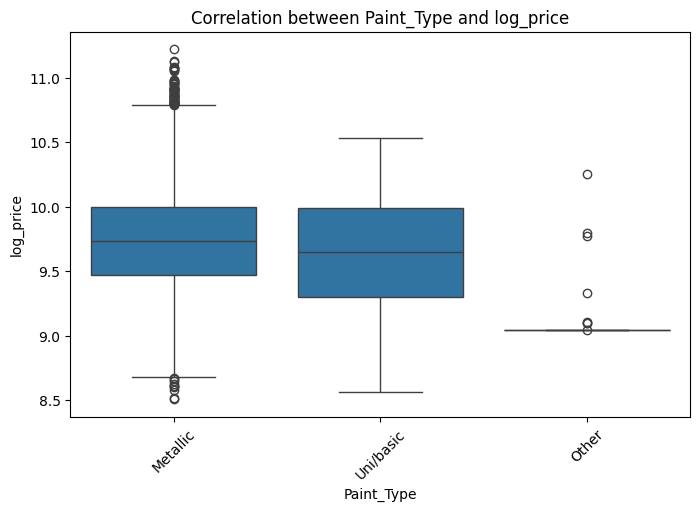

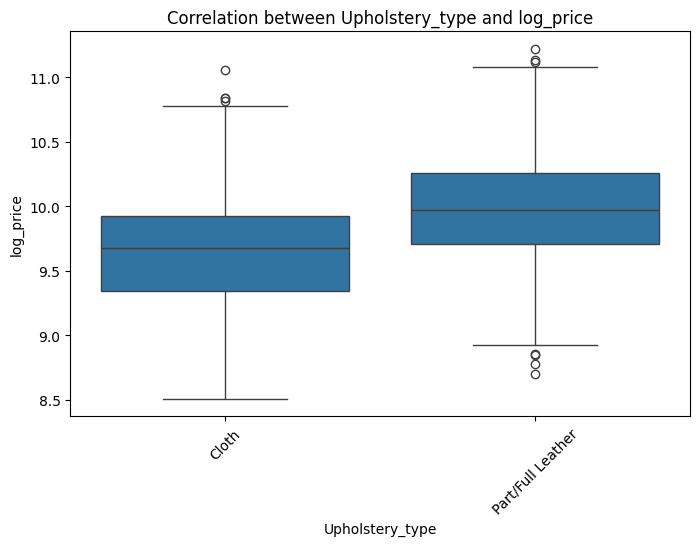

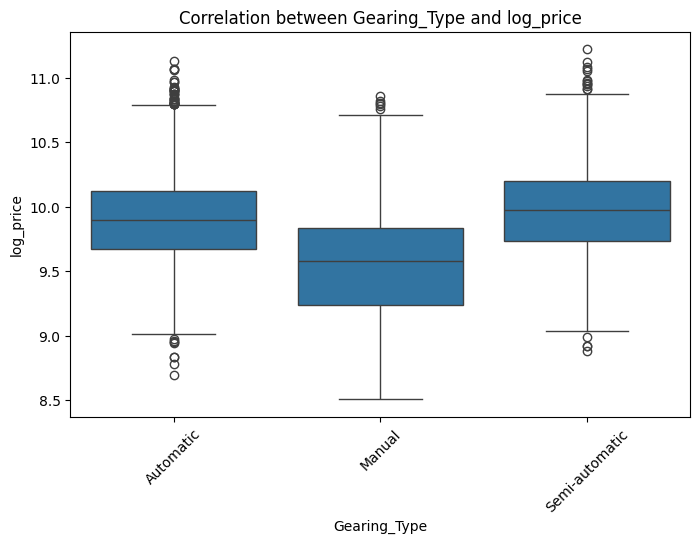

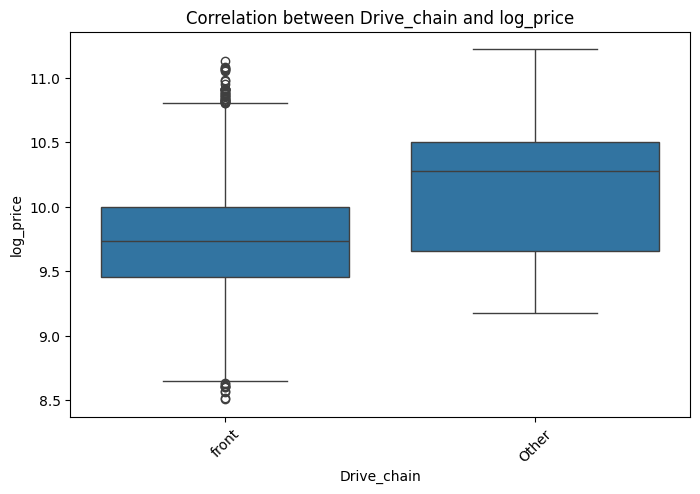


Average log_price by brand:
brand
Audi       9.877589
Renault    9.661338
Opel       9.621755
Name: log_price, dtype: float64

Average log_price by body_type:
body_type
Van              10.294505
Station wagon     9.753394
Sedans            9.716079
Other             9.622857
Compact           9.555660
Name: log_price, dtype: float64

Average log_price by vat:
vat
VAT deductible      9.730221
Price negotiable    9.556223
Name: log_price, dtype: float64

Average log_price by Type:
Type
New-like        9.942604
Used-lightly    9.904539
Used            9.630496
Name: log_price, dtype: float64

Average log_price by Fuel:
Fuel
Diesel     9.734862
Benzine    9.709263
Other      9.639389
Name: log_price, dtype: float64

Average log_price by Paint_Type:
Paint_Type
Metallic     9.725340
Uni/basic    9.638571
Other        9.144455
Name: log_price, dtype: float64

Average log_price by Upholstery_type:
Upholstery_type
Part/Full Leather    9.981333
Cloth                9.642278
Name: log_price, dt

In [32]:
# Comparing average values of target for different categories

categorical_features = ['brand', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type',
       'Upholstery_type', 'Gearing_Type', 'Drive_chain']
# Loop through each categorical feature and plot boxplots
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=feature, y='log_price', data=df)
    plt.title(f'Correlation between {feature} and log_price')
    plt.xticks(rotation=45)
    plt.show()

# Compute group means for each category
for feature in categorical_features:
    print(f"\nAverage log_price by {feature}:")
    print(df.groupby(feature)['log_price'].mean().sort_values(ascending=False))


**Interpretation:**  
Several numerical predictors show strong pairwise correlations, suggesting potential multicollinearity.  
This motivates the use of Variance Inflation Factor (VIF) analysis and regularized regression models.

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

In [33]:
num_cols

Index(['price', 'km', 'Gears', 'age', 'Previous_Owners', 'hp_kW',
       'Inspection_new', 'Displacement_cc', 'Weight_kg', 'cons_comb'],
      dtype='object')

In [34]:
# Outliers present in each column
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
price,15915.0,18024.380584,7381.679318,4950.000000,12850.000000,16900.000000,21900.000000,74600.000000
km,15915.0,32089.995708,36977.214964,0.000000,1920.500000,20413.000000,46900.000000,317000.000000
Gears,15915.0,5.937355,0.704772,5.000000,5.000000,6.000000,6.000000,8.000000
age,15915.0,1.389695,1.121306,0.000000,0.000000,1.000000,2.000000,3.000000
Previous_Owners,15915.0,1.042853,0.339178,0.000000,1.000000,1.000000,1.000000,4.000000
hp_kW,15915.0,88.499340,26.674341,40.000000,66.000000,85.000000,103.000000,294.000000
Inspection_new,15915.0,0.247063,0.431317,0.000000,0.000000,0.000000,0.000000,1.000000
Displacement_cc,15915.0,1428.661891,275.804272,890.000000,1229.000000,1461.000000,1598.000000,2967.000000
Weight_kg,15915.0,1337.700534,199.682385,840.000000,1165.000000,1295.000000,1472.000000,2471.000000
cons_comb,15915.0,4.832124,0.867530,3.000000,4.100000,4.800000,5.400000,9.100000


#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [35]:
# Handle outliers

mask = pd.Series(True, index=df.index)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lowerbound = Q1 - 1.5*IQR
    upperbound = Q3 + 1.5*IQR
    mask &= (df[col] >= lowerbound) & (df[col] <= upperbound)
df_new = df[mask]

### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [36]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9452 entries, 1 to 15791
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   body_type            9452 non-null   object 
 1   price                9452 non-null   int64  
 2   vat                  9452 non-null   object 
 3   km                   9452 non-null   float64
 4   Type                 9452 non-null   object 
 5   Fuel                 9452 non-null   object 
 6   Gears                9452 non-null   float64
 7   Comfort_Convenience  9452 non-null   object 
 8   Entertainment_Media  9452 non-null   object 
 9   Extras               9452 non-null   object 
 10  Safety_Security      9452 non-null   object 
 11  age                  9452 non-null   float64
 12  Previous_Owners      9452 non-null   float64
 13  hp_kW                9452 non-null   float64
 14  Inspection_new       9452 non-null   int64  
 15  Paint_Type           9452 non-null   objec

In [37]:
df_new['Gears'] = df_new['Gears'].astype(int)

/tmp/ipykernel_497/1896066538.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Gears'] = df_new['Gears'].astype(int)


In [38]:
df_new['Previous_Owners'] = df_new['Previous_Owners'].astype('int').astype('object')

/tmp/ipykernel_497/498904911.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Previous_Owners'] = df_new['Previous_Owners'].astype('int').astype('object')


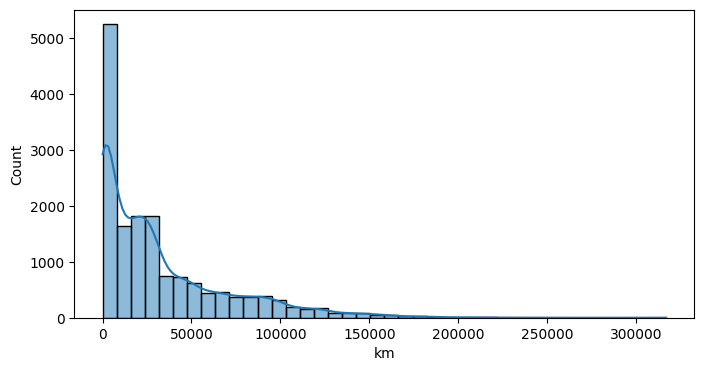

In [39]:
# Plot histograms for target feature
plt.figure(figsize=(8,4))
sns.histplot(data=df_new, x=df['km'], bins=40, kde=True)
plt.xlabel('km')
plt.show()


In [40]:
# Fix/create columns as needed



#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [41]:
# Check unique values in each feature spec column
df_new['comfort_count'] = df_new['Comfort_Convenience'].apply(lambda x: len(x.split(',')))
df_new['entertainment_count'] = df_new['Entertainment_Media'].apply(lambda x: len(x.split(',')))
df_new['extras_count'] = df_new['Extras'].apply(lambda x: len(x.split(',')))
df_new['safety_count'] = df_new['Safety_Security'].apply(lambda x: len(x.split(',')))

/tmp/ipykernel_497/4031169969.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['comfort_count'] = df_new['Comfort_Convenience'].apply(lambda x: len(x.split(',')))
/tmp/ipykernel_497/4031169969.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['entertainment_count'] = df_new['Entertainment_Media'].apply(lambda x: len(x.split(',')))
/tmp/ipykernel_497/4031169969.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

**Feature Engineering Choice:**  
Text-based columns containing multiple comma-separated attributes were converted into count-based numerical features.  
This avoids high-dimensional sparse representations while capturing the overall level of equipment associated with vehicle price.

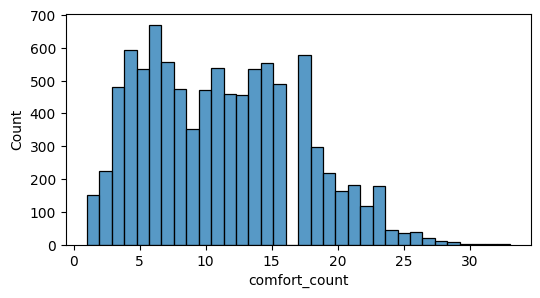

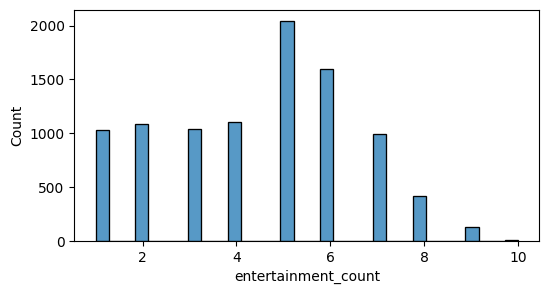

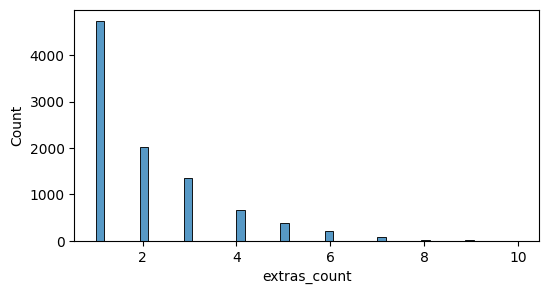

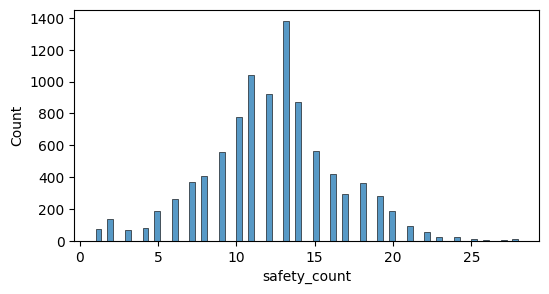

In [42]:
temp = ['comfort_count', 'entertainment_count','extras_count','safety_count']
for col in temp: 
    plt.figure(figsize=(6,3))
    sns.histplot(data=df_new, x=col)
    plt.show()

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [43]:
# Drop features from df
df_new.drop(['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security'],axis=1, inplace=True)

/tmp/ipykernel_497/1806226413.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.drop(['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security'],axis=1, inplace=True)


#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [44]:
category_col = df_new.select_dtypes(include='object').columns

In [45]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9452 entries, 1 to 15791
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   body_type            9452 non-null   object 
 1   price                9452 non-null   int64  
 2   vat                  9452 non-null   object 
 3   km                   9452 non-null   float64
 4   Type                 9452 non-null   object 
 5   Fuel                 9452 non-null   object 
 6   Gears                9452 non-null   int64  
 7   age                  9452 non-null   float64
 8   Previous_Owners      9452 non-null   object 
 9   hp_kW                9452 non-null   float64
 10  Inspection_new       9452 non-null   int64  
 11  Paint_Type           9452 non-null   object 
 12  Upholstery_type      9452 non-null   object 
 13  Gearing_Type         9452 non-null   object 
 14  Displacement_cc      9452 non-null   float64
 15  Weight_kg            9452 non-null   float

In [46]:
# Encode features
df_final = pd.get_dummies(data=df_new, columns=category_col, drop_first=True)

In [47]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9452 entries, 1 to 15791
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   price                              9452 non-null   int64  
 1   km                                 9452 non-null   float64
 2   Gears                              9452 non-null   int64  
 3   age                                9452 non-null   float64
 4   hp_kW                              9452 non-null   float64
 5   Inspection_new                     9452 non-null   int64  
 6   Displacement_cc                    9452 non-null   float64
 7   Weight_kg                          9452 non-null   float64
 8   cons_comb                          9452 non-null   float64
 9   log_price                          9452 non-null   float64
 10  comfort_count                      9452 non-null   int64  
 11  entertainment_count                9452 non-null   int64  
 

#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [48]:
# Split data
# Train-Val-Test split
X = df_final.drop(['price','log_price'],axis=1)
y = df_final['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size = 0.3, random_state = 0)

print('Dimensions of X_train:', X_train.shape); print('Dimensions of y_train:', y_train.shape)
print('Dimensions of X_test:', X_test.shape); print('Dimensions of y_test:', y_test.shape)

Dimensions of X_train: (6616, 29)
Dimensions of y_train: (6616,)
Dimensions of X_test: (2836, 29)
Dimensions of y_test: (2836,)


**Data Splitting:**  
The dataset was split into training and test sets using an 70–30 ratio.  
This ensures sufficient data for model training while preserving an unseen test set for unbiased evaluation.

#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [49]:
# Scale features
scaler = MinMaxScaler()
numerical_columns = X_train.select_dtypes(include = ['int64', 'float64']).columns
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])


**Scaling Strategy:**  
Numerical features were scaled using Min–Max normalization to ensure comparable feature magnitudes for regularized models.  
The scaler was fitted only on the training data and applied to the test data to prevent information leakage.  
Binary dummy variables were left unscaled, as they are already in a suitable range.

## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [50]:
# Initialise and train model
lr_1 = LinearRegression()
lr_1 = lr_1.fit(X_train, y_train)

**Baseline Model:**  
Linear Regression was used as a baseline model to evaluate the effectiveness of regularization techniques applied later.

In [51]:
# Evaluate the model's performance

y_train_pred = lr_1.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse = np.round(rmse, 2)
print('Training RMSE = ', rmse)

y_test_pred = lr_1.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse = np.round(rmse, 2)
print('Testing RMSE = ', rmse)

Training RMSE =  0.12
Testing RMSE =  0.12


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

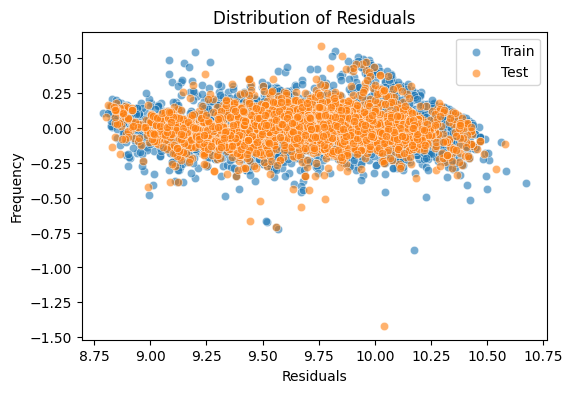

In [52]:
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred
plt.figure(figsize=(6,4))
sns.scatterplot(x = y_train_pred, y = residuals_train, label = 'Train', alpha = 0.6)
sns.scatterplot(x = y_test_pred, y = residuals_test, label = 'Test', alpha = 0.6)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

**Residual Diagnostics:**  
Residuals are randomly scattered around zero with no clear pattern, indicating that linearity and homoscedasticity assumptions are reasonably satisfied.

Check normality in residual distribution

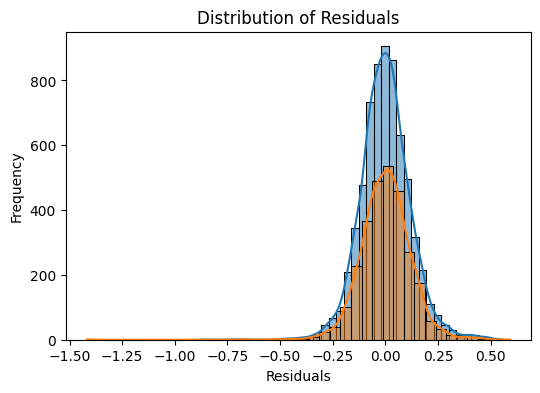

In [53]:
# Check the normality of residuals by plotting their distribution

plt.figure(figsize=(6,4))
sns.histplot(residuals_train, bins=40, kde=True)
sns.histplot(residuals_test, bins=40, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [54]:
# Check for multicollinearity and handle
X = df_final.drop(columns=['price', 'log_price'])
X = X.astype(int)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df.sort_values(by='VIF', ascending=False)

/home/piyush0912/pyspark-env/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
1,Gears,153.032449
5,Displacement_cc,133.183273
26,Drive_chain_front,132.761232
6,Weight_kg,129.699783
7,cons_comb,63.789110
3,hp_kW,59.835210
11,safety_count,24.393456
16,vat_VAT deductible,18.136715
8,comfort_count,14.212334
19,Fuel_Diesel,10.617257


In [55]:
vif_df[vif_df['VIF'] > 10]

,feature,VIF
1,Gears,153.032449
3,hp_kW,59.835210
5,Displacement_cc,133.183273
6,Weight_kg,129.699783
7,cons_comb,63.789110
8,comfort_count,14.212334
11,safety_count,24.393456
16,vat_VAT deductible,18.136715
19,Fuel_Diesel,10.617257
26,Drive_chain_front,132.761232


In [56]:
X = X.drop(columns=['Inspection_new','Displacement_cc','Gears','cons_comb'])

In [57]:
# recompute VIF after dropping
vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df.sort_values(by='VIF', ascending=False)

,feature,VIF
3,Weight_kg,109.238103
22,Drive_chain_front,79.114796
2,hp_kW,45.419525
7,safety_count,24.087244
12,vat_VAT deductible,17.698411
4,comfort_count,13.706033
1,age,9.599888
5,entertainment_count,9.545022
13,Type_Used,8.316099
6,extras_count,5.798641


In [58]:
X = X.drop(columns=['Weight_kg'])

**Interpretation:**  
VIF was used as a diagnostic measure to assess multicollinearity among predictors.  
While some variables exhibit high VIF values, this does not necessarily imply poor predictive performance and is further addressed using regularization techniques.
And no variables were removed solely based on VIF. Instead, multicollinearity was addressed through regularized regression, allowing model performance rather than diagnostic thresholds to guide decisions.

### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [59]:
# List of alphas to tune for Ridge regularisation
param_grid = {'alpha': np.linspace(0.0001, 1, 1000)}


**Ridge Tuning:**  
The Ridge regularization parameter was tuned using cross-validation over a logarithmically spaced range of alpha values to explore both weak and strong regularization regimes.

#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [60]:
# Applying Ridge regression
ridge = Ridge()

# GridSearchCV for tuning Ridge hyperparameters
model_cv = GridSearchCV(estimator=ridge, param_grid = param_grid,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

model_cv.fit(X_train, y_train)

print(model_cv.best_estimator_.n_iter_)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
None


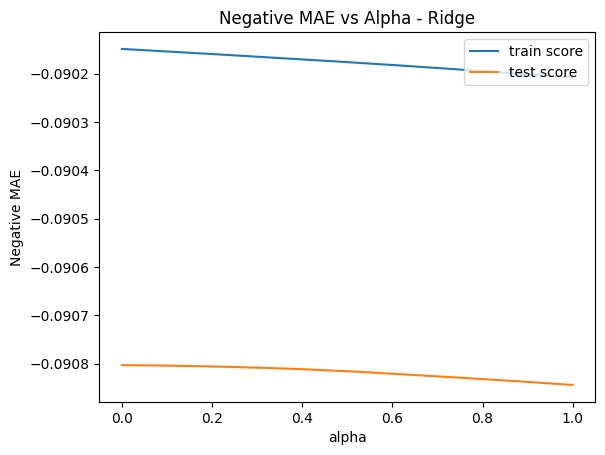

In [61]:
# Plot train and test scores against alpha
cv_results = pd.DataFrame(model_cv.cv_results_)

# Convert alpha to float for better plotting
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

# Plot train and test scores against alpha
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative MAE')

plt.title("Negative MAE vs Alpha - Ridge")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()


Find the best alpha value.

In [62]:
# Best alpha value
best_ridge_alpha = model_cv.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha}")

# Best score (negative MAE)
best_score = model_cv.best_score_
print(f"Best negative MAE: {best_score}")

Best alpha: 0.0001
Best negative MAE: -0.09080306885970768


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [88]:
# Take a smaller range of alpha to test
param_grid = {'alpha': np.linspace(0.0001, 1, 100)}


In [89]:
# Applying Ridge regression

model_cv1 = GridSearchCV(estimator=ridge, param_grid = param_grid,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

model_cv1.fit(X_train, y_train)

print(model_cv1.best_estimator_.n_iter_)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
None


Plot the error-alpha graph again and find the actual optimal value for alpha.

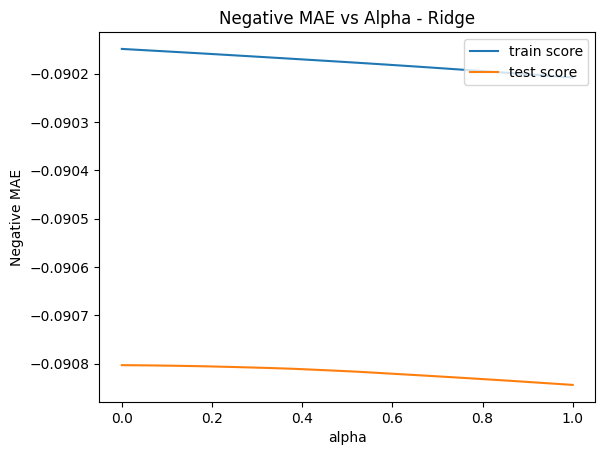

Best alpha: 0.0001
Best negative MAE: -0.09080306885970768


In [90]:
# Plot train and test scores against alpha
cv_results = pd.DataFrame(model_cv1.cv_results_)

# Convert alpha to float for better plotting
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

# Plot train and test scores against alpha
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative MAE')

plt.title("Negative MAE vs Alpha - Ridge")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()


# Best alpha value
best_ridge_alpha = model_cv1.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha}")

# Best score (negative MAE)
best_score = model_cv1.best_score_
print(f"Best negative MAE: {best_score}")

In [87]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model
best_ridge_model = Ridge(alpha = best_ridge_alpha)
best_ridge_model = best_ridge_model.fit(X_train, y_train)

In [67]:
# Show the coefficients for each feature
pd.DataFrame({"Feature": X_train.columns, "Coefficients - LR": lr_1.coef_, "Coefficients - Ridge": best_ridge_model.coef_}).round(2)


,Feature,Coefficients - LR,Coefficients - Ridge
0,km,-0.29,-0.29
1,Gears,0.10,0.10
2,age,-0.24,-0.24
3,hp_kW,0.86,0.86
4,Inspection_new,-0.00,0.00
5,Displacement_cc,-0.21,-0.21
6,Weight_kg,0.17,0.17
7,cons_comb,0.08,0.08
8,comfort_count,0.34,0.34
9,entertainment_count,-0.09,-0.09


In [68]:
# Evaluate the Ridge model on the test data

**Ridge Tuning Result:**  
Cross-validation selected an optimal Ridge regularization parameter of α = 0.01.  
This small but non-zero value indicates that mild regularization slightly improves model stability, while stronger regularization increases bias and degrades performance.

### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [69]:
# List of alphas to tune for Lasso regularisation
param_grid_2 = {'alpha': np.logspace(-4, 1, 50)}

#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [70]:
# Initialise Lasso regression model
lasso = Lasso(max_iter=10000, random_state=42)

model_cv2 = GridSearchCV(estimator=lasso, param_grid = param_grid_2,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

model_cv2.fit(X_train, y_train)

print(model_cv2.best_estimator_.n_iter_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
26


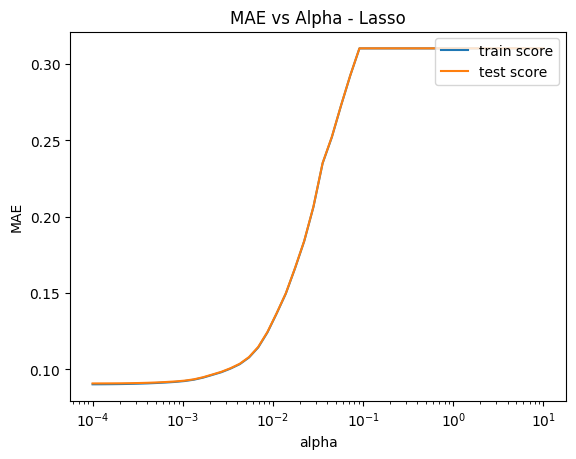

In [71]:
# Plot train and test scores against alpha
cv_results = pd.DataFrame(model_cv2.cv_results_)

# Convert alpha to float for better plotting
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

# Plot train and test scores against alpha
plt.plot(cv_results['param_alpha'], -cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], -cv_results['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MAE')

plt.title("MAE vs Alpha - Lasso")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()

In [72]:
# Best alpha value
best_lasso_alpha = model_cv2.best_params_['alpha']
print(f"Best alpha: {best_lasso_alpha}")

# Best score (negative MAE)
best_score = model_cv2.best_score_
print(f"Best negative MAE: {best_score}")

Best alpha: 0.0001
Best negative MAE: -0.09081766339723718


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [73]:
# List of alphas to tune for Lasso regularization
param_grid_fine = {'alpha': np.logspace(-6, -4, 20)}

In [74]:
# Tuning Lasso hyperparameters
model_cv3 = GridSearchCV(estimator=lasso, param_grid = param_grid_fine,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

model_cv3.fit(X_train, y_train)

print(model_cv2.best_estimator_.n_iter_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
26


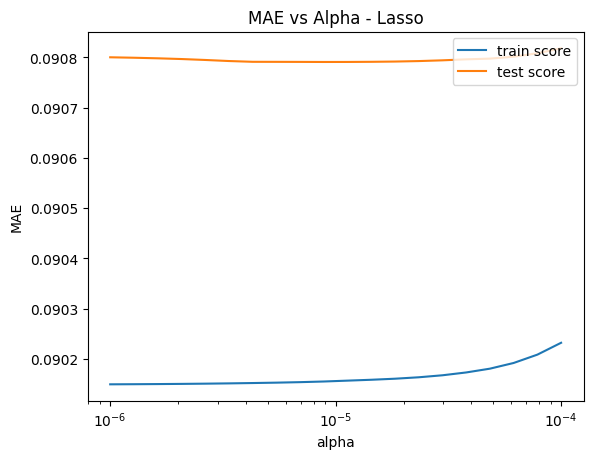

In [75]:
# Plot train and test scores against alpha
cv_results = pd.DataFrame(model_cv3.cv_results_)

# Convert alpha to float for better plotting
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

# Plot train and test scores against alpha
plt.plot(cv_results['param_alpha'], -cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], -cv_results['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MAE')

plt.title("MAE vs Alpha - Lasso")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()

In [76]:
# Best alpha value
best_lasso_alpha = model_cv3.best_params_['alpha']
print(f"Best alpha: {best_lasso_alpha}")

# Best score (negative MAE)
best_score = model_cv3.best_score_
print(f"Best negative MAE: {best_score}")

Best alpha: 8.858667904100832e-06
Best negative MAE: -0.09079052250734829


In [77]:
# Set best alpha for Lasso regression
# Fit the Lasso model on scaled training data
# Get the coefficients of the fitted model
best_lasso_model = Lasso(alpha = best_lasso_alpha)
best_lasso_model = best_lasso_model.fit(X_train, y_train)





In [78]:
# Check the coefficients for each feature
pd.DataFrame({"Feature": X_train.columns, "Coefficients - LR": lr_1.coef_, "Coefficients - Lasso": best_lasso_model.coef_}).round(2)


,Feature,Coefficients - LR,Coefficients - Lasso
0,km,-0.29,-0.29
1,Gears,0.10,0.10
2,age,-0.24,-0.24
3,hp_kW,0.86,0.86
4,Inspection_new,-0.00,0.00
5,Displacement_cc,-0.21,-0.21
6,Weight_kg,0.17,0.17
7,cons_comb,0.08,0.08
8,comfort_count,0.34,0.34
9,entertainment_count,-0.09,-0.09


In [79]:
# Evaluate the Lasso model on the test data

**Interpretation:**  
The optimal Lasso alpha was found at the lower boundary of the search space, indicating that minimal regularization yields the best performance.  
This suggests that the dataset does not exhibit strong sparsity and that Lasso-based feature selection is not beneficial in this case.

### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [80]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Ridge
ridge = Ridge(alpha=best_ridge_alpha)
ridge.fit(X_train, y_train)

# Lasso
lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [81]:
# Compare metrics for each model
metrics_df = pd.DataFrame({
    "Linear Regression": regression_metrics(y_test, y_pred_lr),
    "Ridge Regression": regression_metrics(y_test, y_pred_ridge),
    "Lasso Regression": regression_metrics(y_test, y_pred_lasso)
}).T

metrics_df


,MAE,RMSE,R2
Linear Regression,0.089543,0.120346,0.895732
Ridge Regression,0.089543,0.120346,0.895732
Lasso Regression,0.089540,0.120340,0.895742


**Model Comparison:**  
Linear Regression and Ridge achieve nearly identical performance, while Lasso performs marginally worse.  
This confirms that regularization does not provide a significant advantage after preprocessing and log transformation.

#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [82]:
# Compare highest coefficients and coefficients of eliminated features
pd.DataFrame({"Feature": X_train.columns, "Coefficients - LR": lr_1.coef_, "Coefficients - Lasso": best_lasso_model.coef_,"Coefficients - Ridge": best_ridge_model.coef_}).round(4)


,Feature,Coefficients - LR,Coefficients - Lasso,Coefficients - Ridge
0,km,-0.2860,-0.2858,-0.2860
1,Gears,0.1020,0.1020,0.1020
2,age,-0.2354,-0.2356,-0.2354
3,hp_kW,0.8647,0.8645,0.8646
4,Inspection_new,-0.0000,0.0000,0.0000
5,Displacement_cc,-0.2104,-0.2092,-0.2103
6,Weight_kg,0.1743,0.1747,0.1743
7,cons_comb,0.0773,0.0757,0.0773
8,comfort_count,0.3429,0.3417,0.3429
9,entertainment_count,-0.0914,-0.0914,-0.0915


**Coefficient Analysis:**  
The similarity between Linear Regression and Ridge coefficients indicates that the optimal Ridge regularization strength is close to zero.  
This suggests that, after preprocessing, multicollinearity does not significantly affect coefficient stability or predictive performance.

## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

Conclusions

This project demonstrates that careful preprocessing and feature engineering can significantly stabilize a regression problem, often reducing the need for complex modeling techniques. After cleaning the dataset, consolidating categorical variables, engineering count-based features, and applying a log transformation to the target variable, the price prediction task became well-behaved and suitable for linear modeling.

Despite the presence of multicollinearity indicated by high VIF values, regularized models did not outperform standard Linear Regression. Cross-validation consistently selected regularization parameters close to zero for both Ridge and Lasso, resulting in coefficients that were nearly identical to those of the unregularized model. This indicates that multicollinearity did not meaningfully affect predictive performance once preprocessing was completed.

Lasso regression, in particular, did not provide additional benefits through feature selection. The optimal alpha value was found at the lower boundary of the search range, suggesting that the dataset does not exhibit strong sparsity and that most predictors contribute useful information. Enforcing sparsity in this case introduced unnecessary bias without improving generalization.

Key Takeaways

Data preparation had a greater impact than model complexity
Log-transforming the target variable, reducing categorical sparsity, and engineering compact numeric features contributed more to performance improvements than switching between Linear, Ridge, and Lasso regression.

High multicollinearity does not automatically imply poor model performance
While VIF revealed correlated predictors, validation results showed that this correlation did not degrade predictive accuracy. Regularization should be applied based on empirical improvement, not diagnostic metrics alone.

Regularization is a tool, not a requirement
Ridge and Lasso were correctly evaluated using cross-validation. Since they did not reduce error compared to Linear Regression, retaining the simpler model is both justified and preferable.

Lasso is effective only when true sparsity exists
In the absence of many irrelevant features, Lasso-based feature selection can be counterproductive and lead to underfitting.

Model behavior itself is an insight
Identical coefficients across Linear, Ridge, and Lasso models are not a failure of implementation but an indication that the underlying data is already well-structured.

Final note:
A strong linear baseline combined with thoughtful preprocessing can outperform more complex techniques. Understanding when regularization is unnecessary is just as important as knowing how to apply it.